## Subpoint (a): Geometric Mean of Distances

In this step, we define our core function to calculate the geometric mean of distances from each point $x_j$ to all other points in a given vector. 

According to the instructions, for a given point $x_j$ and a set of $N$ points, the geometric mean is calculated as the $(N-1)$-th root of the product of absolute distances to all remaining points:
$$G(x_j) = \left( \prod_{k \neq j} |x_j - x_k| \right)^{\frac{1}{N-1}}$$

We use the `numpy` library and its array manipulation capabilities to calculate these values efficiently.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from numpy.polynomial.legendre import legroots

# 1. Define a function to calculate the geometric mean of distances
def geometric_mean_distances(x):
    n_points = len(x)
    y = np.zeros_like(x, dtype=float)
    
    # Calculate the value for each point in the vector
    for i in range(n_points):
        # Array of distances to all other points (excluding itself)
        distances = np.abs(x[i] - np.delete(x, i))
        y[i] = np.prod(distances) ** (1.0 / len(distances))
        
    return y

## Subpoint (b): Generation of Interpolation Nodes

To analyze the Runge phenomenon, we need to compare different distributions of interpolation nodes within the interval $[-1, 1]$. We implement functions to generate three types of nodes:

1. **Uniform Nodes:** Evenly spaced points from $x_0 = -1$ to $x_n = 1$.
2. **Chebyshev Nodes:** Defined by the trigonometric formula $x_j = \cos(\theta_j)$ where $\theta_j = \frac{2j-1}{2N}\pi$. This specific distribution clusters points near the boundaries of the interval.
3. **Legendre Nodes:** Calculated as the roots of the Legendre polynomial of degree $N$, utilizing the `numpy.polynomial.legendre.legroots` function.

*(Note: For an interpolation with parameter $n$, we generate $N = n+1$ points, representing indices from $0$ to $n$).*

In [7]:
# 1. Function for uniformly distributed nodes
def get_uniform_nodes(n):
    # n+1 evenly spaced points between -1 and 1
    return np.linspace(-1, 1, n + 1)

# 2. Function for Chebyshev nodes
def get_chebyshev_nodes(n):
    # n+1 Chebyshev nodes based on the mathematical definition
    N = n + 1
    j = np.arange(1, N + 1)
    return np.cos((2 * j - 1) / (2 * N) * np.pi)

# 3. Function for Legendre nodes
def get_legendre_nodes(n):
    # Roots of the Legendre polynomial of degree n+1
    coeffs = np.zeros(n + 2)
    coeffs[n + 1] = 1
    return legroots(coeffs)

## Subpoint (c): Evaluating and Visualizing Node Distributions

We evaluate our distance function for degrees $n = 5, 10$, and $20$. 

By plotting the geometric mean of distances on the y-axis and the node positions on the x-axis, we can visually compare how different node generation strategies behave. Uniform nodes exhibit a significant drop near the edges, which directly contributes to the numerical instability known as the **Runge phenomenon**. In contrast, Chebyshev and Legendre nodes maintain a more balanced distance profile across the interval, stabilizing high-degree polynomial interpolation.

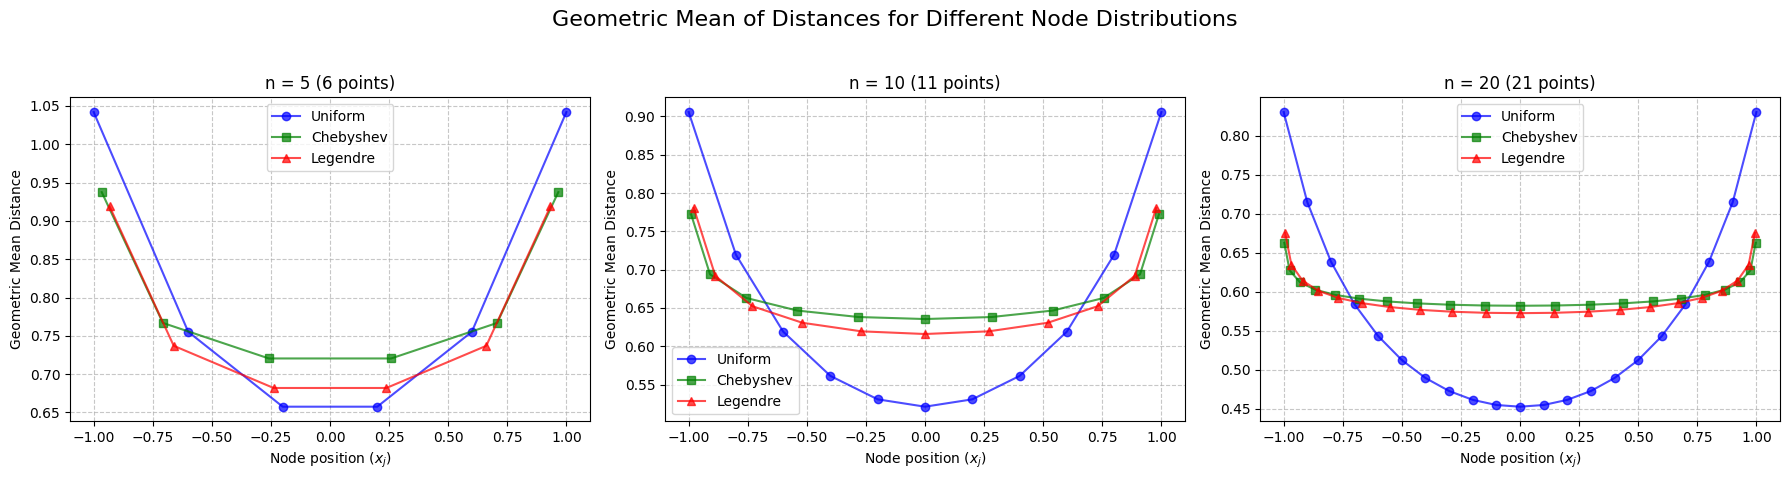

Sample node positions for n = 5:
Uniform:   [-1.  -0.6 -0.2  0.2  0.6  1. ]
Chebyshev: [ 0.966  0.707  0.259 -0.259 -0.707 -0.966]
Legendre:  [-0.932 -0.661 -0.239  0.239  0.661  0.932]


In [10]:
# 1. Define the degrees (n) to evaluate
n_values = [5, 10, 20]

# 2. Set up the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Geometric Mean of Distances for Different Node Distributions", fontsize=16)

# 3. Iterate through each n and plot the results
for idx, n in enumerate(n_values):
    ax = axes[idx]
    
    # Generate nodes
    x_uni = get_uniform_nodes(n)
    x_cheb = get_chebyshev_nodes(n)
    x_leg = get_legendre_nodes(n)
    
    # Calculate geometric means
    y_uni = geometric_mean_distances(x_uni)
    y_cheb = geometric_mean_distances(x_cheb)
    y_leg = geometric_mean_distances(x_leg)
    
    # Plotting the curves
    ax.plot(x_uni, y_uni, 'o-', label='Uniform', color='blue', alpha=0.7)
    ax.plot(x_cheb, y_cheb, 's-', label='Chebyshev', color='green', alpha=0.7)
    ax.plot(x_leg, y_leg, '^-', label="Legendre", color='red', alpha=0.7)
    
    # Formatting
    ax.set_title(f"n = {n} ({n+1} points)")
    ax.set_xlabel('Node position ($x_j$)')
    ax.set_ylabel('Geometric Mean Distance')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Print sample node positions for n=5 to verify clustering behavior
sample_n = 5
print(f"Sample node positions for n = {sample_n}:")
print(f"Uniform:   {np.round(get_uniform_nodes(sample_n), 3)}")
print(f"Chebyshev: {np.round(get_chebyshev_nodes(sample_n), 3)}")
print(f"Legendre:  {np.round(get_legendre_nodes(sample_n), 3)}")